# Introduction to the Data

This data specifically contains all of the neurons in the entorhinal cortex (EC), extracted from the following source:
https://alleninstitute.github.io/abc_atlas_access/descriptions/MERFISH-C57BL6J-638850-imputed.html

For more details, see the original paper:
https://www.nature.com/articles/s41586-023-06812-z

In [2]:
# Uncomment the following lines to install the required packages if you haven't already
%pip install brainrender
%pip install anndata
%pip install scanpy
%pip install vedo
%pip install igraph

     ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
     ---------------------------------------- 2.7/2.7 MB 17.8 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
     ---------------------------------------- 0.0/536.6 kB ? eta -:--:--
     ---------------------------------------- 536.6/536.6 kB 13.8 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   -------------------------------------

In [3]:
# Import packages for data manipulation and visualization
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for neuron visualizations

from brainrender import Scene
from brainrender.actors import Points

import vedo
vedo.settings.default_backend= 'vtk'

The EC data is stored in an `anndata` object: https://anndata.scverse.org/en/stable/. 
The `anndata` format is designed for the storage of Annotated Matrix data. 
It is centered around a core matrix - `anndata.X` - in which rows are cells (observations) and genes are columns (variables).
Importantly, both the rows and the columns of this matrix are indexed, and have associated metadata.

- `anndata.obs` is a dataframe containing all cellular metadata. Rows = Cells, Columns = Metadata (e.g. cell type)
- `anndata.var` is a dataframe containing all gene-level metadata. Rows = Genes, Columns = Metadata (e.g. alternative gene symbols)


In [4]:
# load EC data (imputed MERFISH) object

source = "ec_obj_imputed_log2.h5ad"

ec_data = ad.read_h5ad(source)

print(ec_data)

AnnData object with n_obs × n_vars = 48615 × 8460
    obs: 'brain_section_label', 'class', 'subclass', 'supertype', 'structure', 'substructure', 'x_ccf', 'y_ccf', 'z_ccf'
    var: 'gene_symbol'


Let's start by taking a brief look at the core matrix of gene expression and plot some basic statistics (mean vs standard deviation).

In [5]:
# Let's take a brief look at the core matrix
ec_data.X[0:5]


array([[0.00397 , 0.137   , 0.1438  , ..., 0.      , 0.      , 0.      ],
       [0.005955, 0.1145  , 0.1251  , ..., 0.      , 0.      , 0.      ],
       [0.00397 , 0.2433  , 0.1274  , ..., 0.      , 0.      , 0.      ],
       [0.001986, 0.2413  , 0.1993  , ..., 0.      , 0.      , 0.      ],
       [0.00397 , 0.0409  , 0.02443 , ..., 0.      , 0.      , 0.      ]],
      shape=(5, 8460), dtype=float16)

In [6]:
# Create a pandas DataFrame from the AnnData object for easier manipulation
df = pd.DataFrame(ec_data.X, columns=ec_data.var_names)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48615 entries, 0 to 48614
Columns: 8460 entries, ENSMUSG00000026676 to ENSMUSG00000029695
dtypes: float16(8460)
memory usage: 784.5 MB


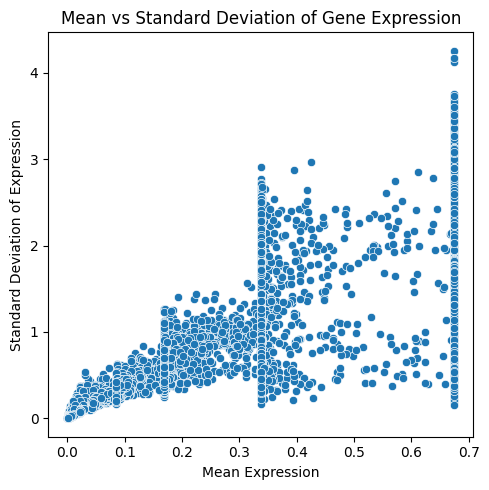

In [7]:
# Use pandas describe function to get summary statistics of the data and plot mean expression and variance for each gene    
mean_df = df.mean()
std_df = df.std()

figs, axes = plt.subplots(1, 1, figsize=(5, 5))
sns.scatterplot(x=mean_df, y=std_df, ax=axes)
axes.set_xlabel("Mean Expression")
axes.set_ylabel("Standard Deviation of Expression")
axes.set_title("Mean vs Standard Deviation of Gene Expression")
plt.tight_layout()
plt.show()


We have added a variety of cellular metadata to this object.
The `class`, `subclass` and `supertype` metadata variables annotate each cell with a canonical transcriptomic cell type (based on the cell taxonomy developed by the Allen Brain Institute). 
These metadata variables are nested. Classes contain subclasses, and subclasses contain supertypes.

The `x_ccf`, `y_ccf`, and `z_ccf` variables together map the location of each cell in the (base 25um) Common Coordinate Framework which describes the average mouse brain.
X-axis = anterior (front of the brain) - posterior (back of the brain)
Y-axis = dorsal (top of the brain) - ventral (bottom of the brain)
Z-Axis = left to right 

The `structure` and `substructure` metadata variables assign each cell to a brain region, based on the aforementioned CCF coordinates.

First, lets visualize all of our neurons within the mouse brain.

In [11]:
# Visualize neurons in 3D using brainrender
neurons = np.array(ec_data.obs[['x_ccf', 'y_ccf', 'z_ccf']])
points = Points(neurons, radius=20, colors="orange")

# Create a brainrender scene
scene = Scene(atlas_name="allen_mouse_25um", title="Visualizing EC Neurons in 3D")

# add neurons
scene.add(points)

# add canonial MEC and LEC region meshes
lec = scene.add_brain_region("ENTl", alpha=0.1, color="blue")
mec = scene.add_brain_region("ENTm", alpha=0.1, color="blue")

scene.add(lec)
scene.add(mec)

# Render
scene.render()

As expected, all of our cells are within the Entorhinal Cortex.
We can also see a consequence of the experiment here. This data was generated by taking coronal slices from the brain, at specific intervals (in this case 200um), and sequencing the cells within.
The cells are therefore organized in discrete slices along the X-axis (anterior-posterior) within the brain.

Now we produce a few more brainrender visualizations, grouping and colouring cells according to different metadata values each time.
For the sake of clarity, we first extract the cell metadata information as a separate table.

In [12]:
cell_metadata = ec_data.obs
cell_metadata.head(n = 5)

,brain_section_label,class,subclass,supertype,structure,substructure,x_ccf,y_ccf,z_ccf
cell_label,,,,,,,,,
1018093344100490327-3,C57BL6J-638850.19,03 OB-CR Glut,036 HPF CR Glut,0135 HPF CR Glut_1,ENTm,ENTm1,10187.352431,3058.025140,8767.202589
1018093343102220029,C57BL6J-638850.24,03 OB-CR Glut,036 HPF CR Glut,0135 HPF CR Glut_1,ENTm,ENTm2,9552.388366,5703.533695,2455.997510
1019171912100520248,C57BL6J-638850.27,03 OB-CR Glut,036 HPF CR Glut,0135 HPF CR Glut_1,ENTm,ENTm3,8960.087708,6176.805722,2417.074366
1017092617102590124,C57BL6J-638850.25,03 OB-CR Glut,036 HPF CR Glut,0135 HPF CR Glut_1,ENTm,ENTm3,9610.027924,5217.053289,8901.322743
1018093343100500636-1,C57BL6J-638850.24,03 OB-CR Glut,036 HPF CR Glut,0135 HPF CR Glut_1,ENTm,ENTm1,9865.030167,4454.612706,8784.204463


C:\Users\ricca\AppData\Local\Temp\ipykernel_13196\2266805309.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90, ha='right')
C:\Users\ricca\AppData\Local\Temp\ipykernel_13196\2266805309.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90, ha='right')
C:\Users\ricca\AppData\Local\Temp\ipykernel_13196\2266805309.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=90, ha='right')


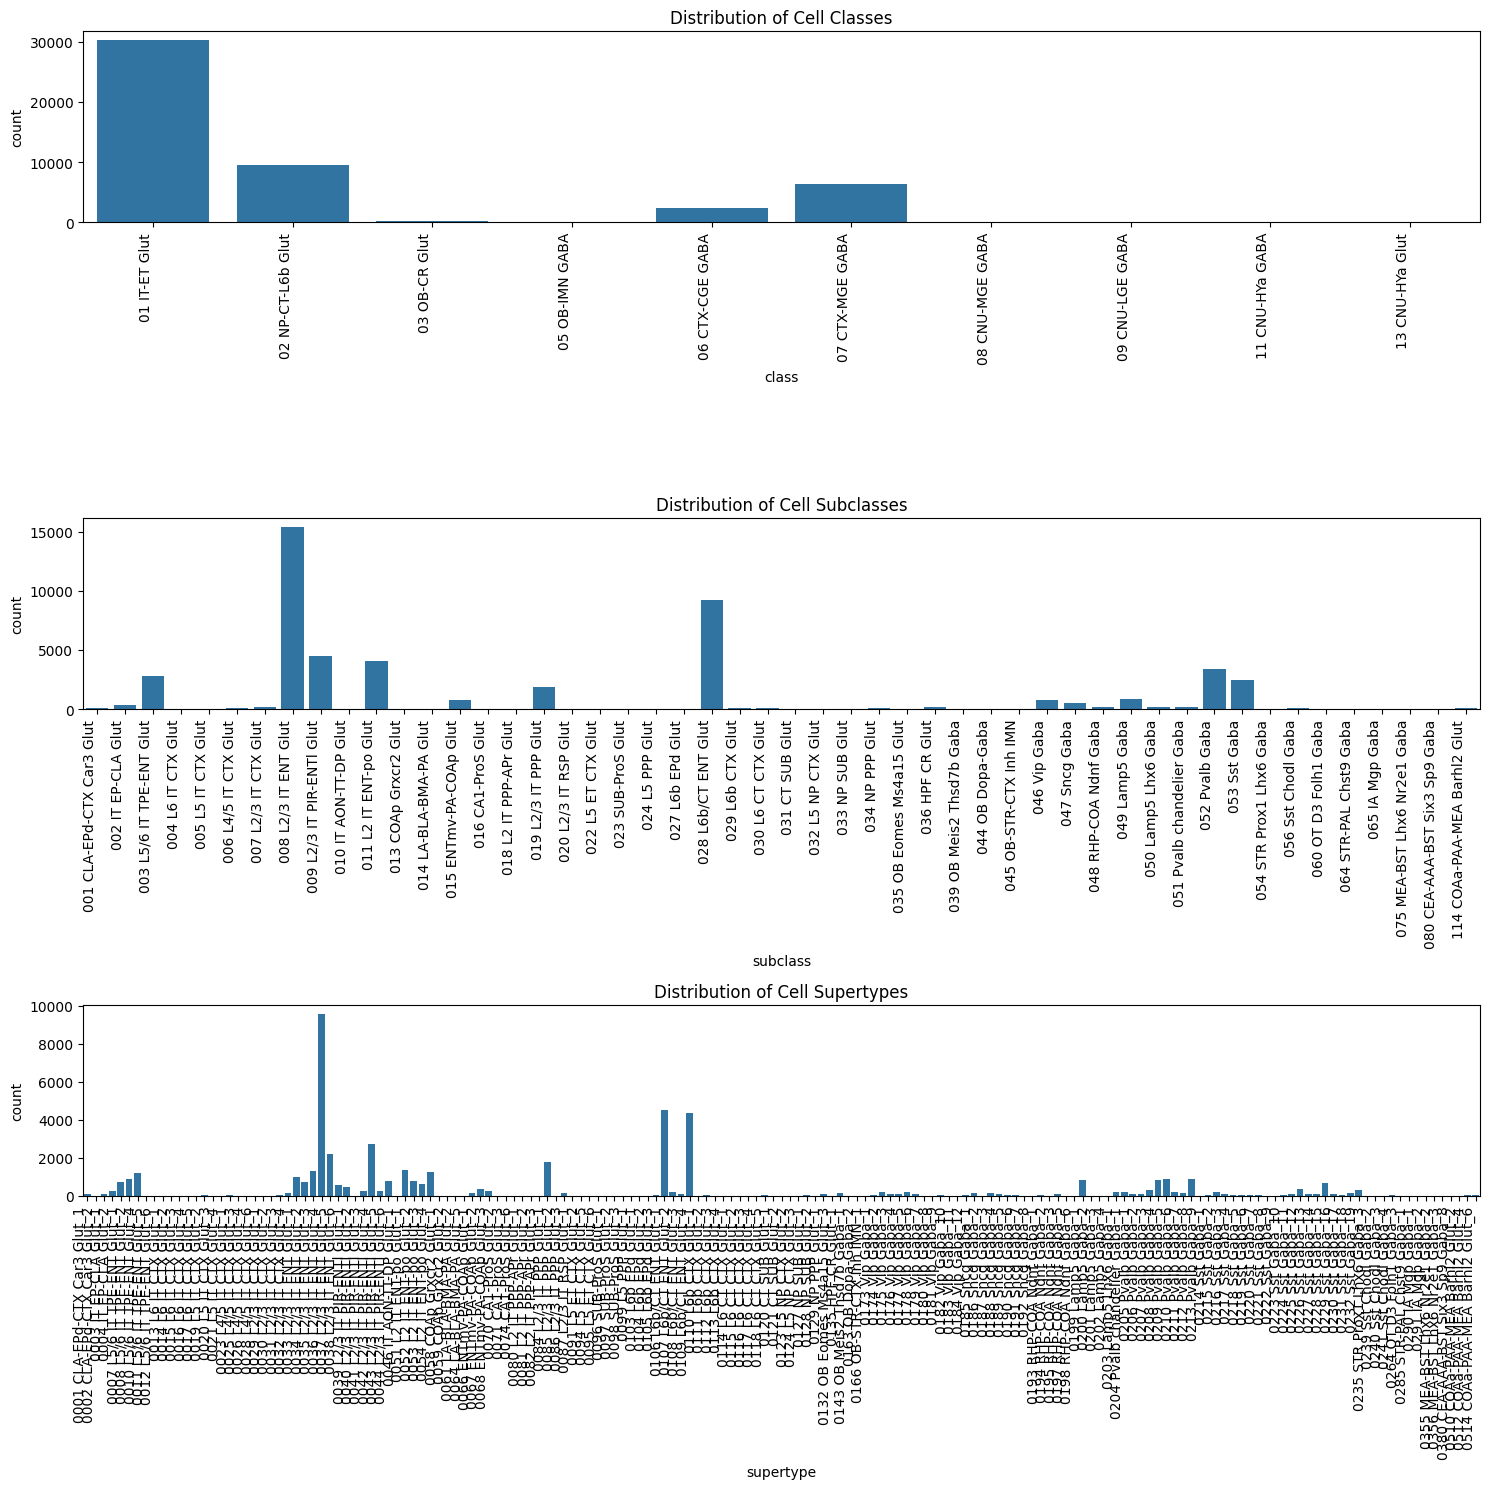

In [13]:
# Visualize the distribution of cell types in the dataset
figs, axes = plt.subplots(3, 1, figsize=(15, 15))
sns.countplot(x='class', data=cell_metadata, ax=axes[0])
axes[0].set_title("Distribution of Cell Classes")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90, ha='right')
sns.countplot(x='subclass', data=cell_metadata, ax=axes[1])
axes[1].set_title("Distribution of Cell Subclasses")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90, ha='right')
sns.countplot(x='supertype', data=cell_metadata, ax=axes[2])
axes[2].set_title("Distribution of Cell Supertypes")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=90, ha='right') 
plt.tight_layout()
plt.show()

In [19]:
# Colour by Region

mec_cells = cell_metadata[cell_metadata["structure"] == "ENTm"]
mec_coords = np.array(mec_cells[["x_ccf", "y_ccf", "z_ccf"]])
mec_points = Points(mec_coords, radius=20, colors="orange")

lec_cells = cell_metadata[cell_metadata["structure"] == "ENTl"]
lec_coords = np.array(lec_cells[["x_ccf", "y_ccf", "z_ccf"]])
lec_points = Points(lec_coords, radius=20, colors="green")

# Create a brainrender scene
scene = Scene(atlas_name="allen_mouse_25um", title="EC Neurons (Coloured by Region)")

# add neurons
scene.add(mec_points)
scene.add(lec_points)

# add canonial MEC and LEC region meshes
lec = scene.add_brain_region("ENTl", alpha=0.1, color="blue")
mec = scene.add_brain_region("ENTm", alpha=0.1, color="blue")

scene.add(lec)
scene.add(mec)

# Render
scene.render()


In [18]:
# Visualize specific cell types - in this case the cell types enriched in EC L5a.

# 034 NP PPP Glut: cell type enriched in medial EC L5a.
np_data = cell_metadata[cell_metadata["subclass"] == '034 NP PPP Glut']
np_coords = np.array(np_data[["x_ccf", "y_ccf", "z_ccf"]])
np_points = Points(np_coords, radius = 20, colors="blue")

# 003 L5/6 IT TPE-ENT Glut: cell type enriched in lateral EC L5a
l56_data = cell_metadata[cell_metadata["subclass"] == '003 L5/6 IT TPE-ENT Glut']
l56_coords =np.array(l56_data[["x_ccf", "y_ccf", "z_ccf"]])
l56_points = Points(l56_coords, radius = 20, colors="green")

# Create a brainrender scene
scene = Scene(atlas_name="allen_mouse_25um", title="EC Neurons (Coloured by Cell Type)")

# add neurons
scene.add(np_points)
scene.add(l56_points)

# add canonial MEC and LEC region meshes
lec = scene.add_brain_region("ENTl", alpha=0.1, color="blue")
mec = scene.add_brain_region("ENTm", alpha=0.1, color="blue")

scene.add(lec)
scene.add(mec)

# Render
scene.render()


The SCANPY package (https://scanpy.readthedocs.io/en/stable/) provides the standard framework for the analysis of single-cell annData objects in Python.

Our data has already been rigously quality controlled and then normalized by the authors of the original paper. The gene-set has also already been optimized to differentiate between the canonical clusters, and various cluster annotations have been provided.

We can therefore skip a few steps in the standard analysis pipeline, and proceed directly to visualization.

A tutorial covering the "standard" analysis pipeline for scRNA-seq data is available here:
https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html


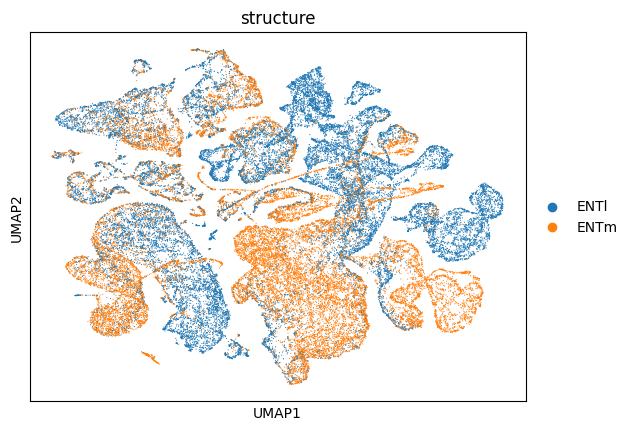

In [17]:
# calculate PCA
sc.tl.pca(ec_data)

# calculate neighbourhood graph
sc.pp.neighbors(ec_data)

# calculate UMAP
sc.tl.umap(ec_data)

# UMAP, coloured by brain region
sc.pl.umap(ec_data, color = "structure")

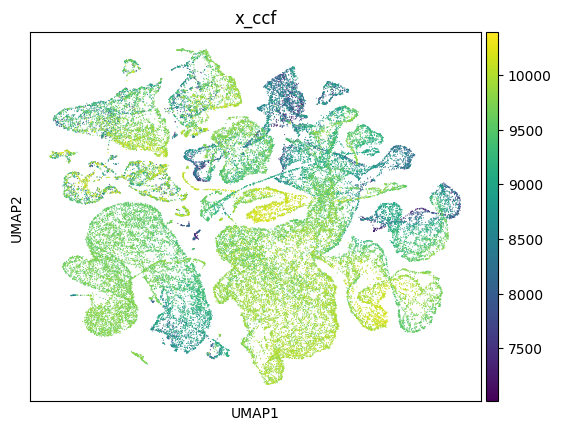

In [20]:
# UMAP - colour by cell location (x_ccf)
sc.pl.umap(ec_data, color = "x_ccf")

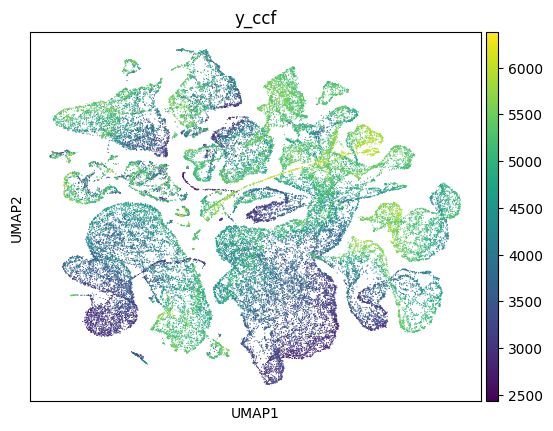

In [21]:
# UMAP - colour by cell location (y_ccf)
sc.pl.umap(ec_data, color = "y_ccf")

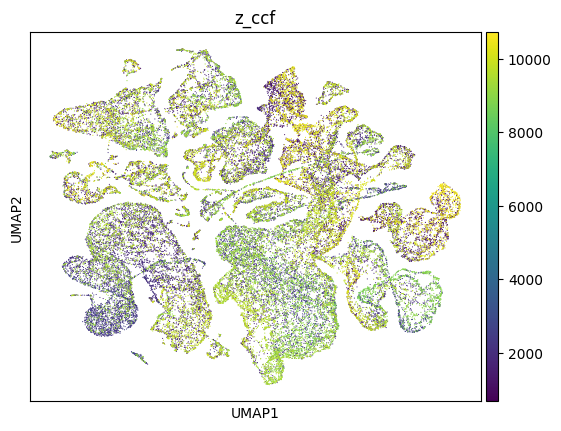

In [22]:
# UMAP - colour by cell location (z_ccf)
sc.pl.umap(ec_data, color = "z_ccf")

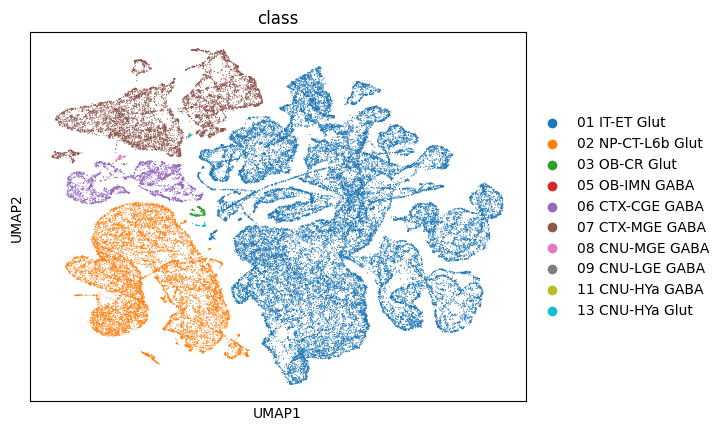

In [23]:
# UMAP - colour by cell type (class)
sc.pl.umap(ec_data, color = "class")

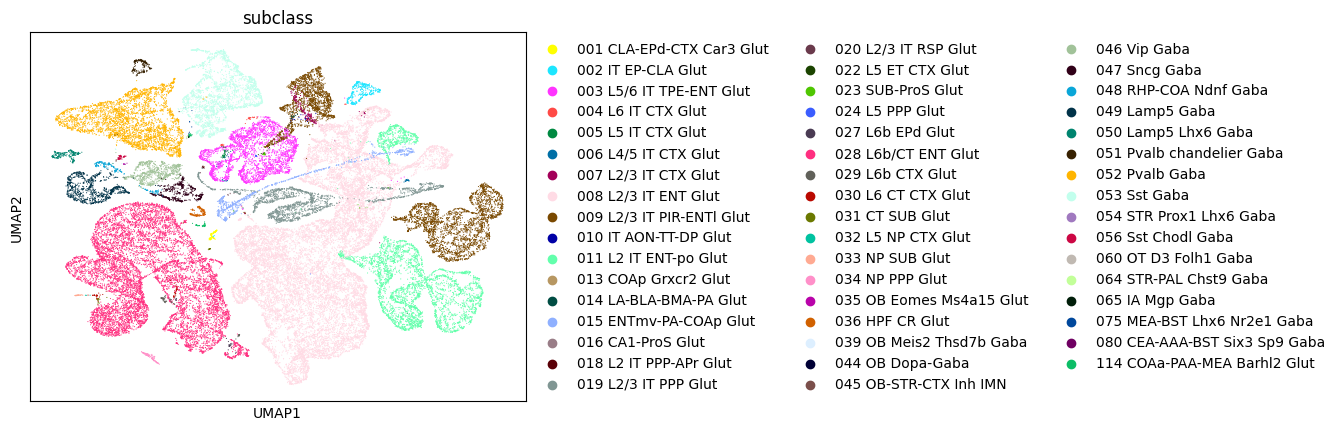

In [24]:
# UMAP - colour by cell type (subclass)
sc.pl.umap(ec_data, color = "subclass")

There are many, many supertypes in this dataset - so much so that trying to colour by supertype overwhelms SCANPY and results in every cell being assigned the same, default grey colour.

Scanpy also contains functionality for various clustering algorithms.

Here we run a popular clustering algorithm in single-cell - the Leiden Graph Clustering method - and visualize our results using the UMAP.

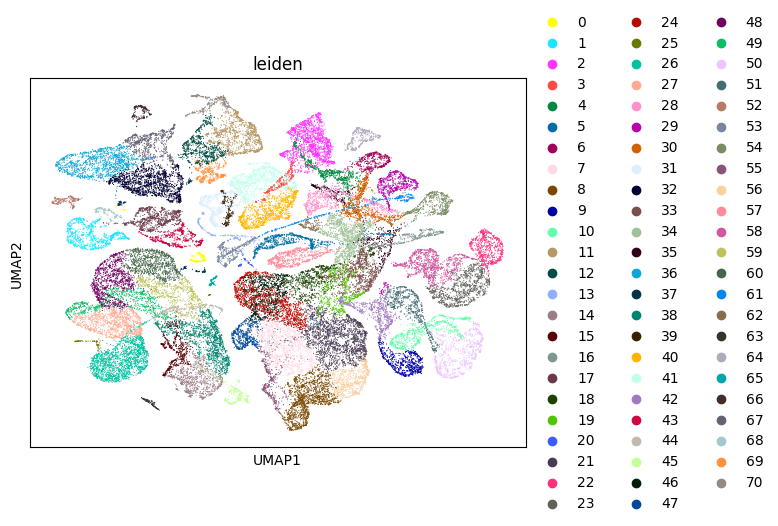

In [25]:
# For simplicity here, we use only 2 iterations of the Leiden algorithm, 
# but in practice you would want to use more iterations and test different resolutions to find the optimal clustering for your data.
sc.tl.leiden(ec_data, flavor="igraph", n_iterations=2)

sc.pl.umap(ec_data, color = "leiden")

In [ ]:
# Add any additional libraries or submodules below

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns


# sklearn modules
import sklearn

#Pipeline
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,classification_report, ConfusionMatrixDisplay
from sklearn.metrics import  RocCurveDisplay, roc_auc_score, accuracy_score, PrecisionRecallDisplay
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.compose import make_column_transformer
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier

#Statistical libraries
from scipy.stats import chi2_contingency

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Define a range of n_estimators to test
n_est = np.linspace(10, 1000, 5, dtype=int)

#Initialize lists to store training and OOB scores
train_scores = []
oob_scores = []

#Fit a random forest model for each value of n_estimators and store the training and OOB scores
for n in n_est:
    rf = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        bootstrap=True,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train_transformed_df, y_train)
    train_scores.append(rf.score(X_train_transformed_df, y_train))
    oob_scores.append(rf.oob_score_)

#Plot the training and OOB scores as a function of n_estimators
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.set_xlabel("n_estimators")
ax.set_ylabel("score")
ax.plot(n_est, train_scores, marker="o", label="train")
ax.plot(n_est, oob_scores, marker="o", label="oob")
ax.legend()
plt.show()

In [ ]:
#Random forest classifier predict supertype from location 
# Pipeline: preprocessing + random forest
rf_pipe = make_pipeline(
    preprocessor,
    RandomForestClassifier(
        random_state=0,
        n_jobs=-1
    )
)

# Small but reasonable grid
param_grid = {
    "randomforestclassifier__n_estimators": [300],
    "randomforestclassifier__max_depth": [None, 10],
    "randomforestclassifier__min_samples_split": [2, 5],
    "randomforestclassifier__min_samples_leaf": [1, 2],
    "randomforestclassifier__max_features": ["sqrt", 0.5]
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Grid search
rf_gs = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    scoring=["accuracy", "f1", "recall", "precision", "roc_auc"],
    cv=cv,
    refit="roc_auc",
    return_train_score=True,
    n_jobs=-1
)

# Fit on training data
rf_gs.fit(X_train, y_train)

# Best tuned pipeline
best_rf_pipe = rf_gs.best_estimator_

# Test set evaluation
acc_rf = best_rf_pipe.score(X_test, y_test)
print("Random forest test set accuracy:", round(acc_rf, 4))

#Compute AUC on the test set
y_proba_rf = best_rf_pipe.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"Random forest AUC: {auc_rf:.4f}")

print("Best RF parameters:")
print(rf_gs.best_params_)

#Print classification report
print(classification_report(y_test, best_rf_pipe.predict(X_test), 
                            target_names=["No Depression", "Depression"]))

# Feature importances
best_preprocessor = best_rf_pipe[0]
best_rf_model = best_rf_pipe[-1]

# Get the names of the transformed features after preprocessing
feature_names = best_preprocessor.get_feature_names_out()

# Build a DataFrame of feature importances
rf_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": best_rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(rf_importance_df.head(20))